In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
import time
import datetime as dt
import folium
import branca.colormap as cm

In [2]:
test_data = r'C:\Users\bmaro\OneDrive\Desktop\New folder'
print(os.listdir(test_data))

['22007209 2025-07-07 17_56_23 EDT (Data EDT).xlsx', 'CAPA2246_070725_213313_0.csv', 'CAPA2246_070725_213325_0.csv', 'CAPA2246_070725_213330_0.csv', 'local_ASOS.csv', 'sensor01_data_20250726_055919.csv', 'sensor01_data_20250726_120235.csv', 'sensor01_data_20250726_150456.csv', 'sensor03_data_20250726_055916.csv', 'sensor03_data_20250726_120229.csv', 'sensor03_data_20250726_150453.csv', 'sensor03_data_20250726_204838.csv', 'sensor03_data_20250727_131829.csv', 'sensor_data_20250707_141348.csv']


In [3]:
def create_df(csv_file):
    df = pd.read_csv(csv_file)
    df = df.drop(df.index[0:6])   # The first few lines typically read funny, I will drop. First 30 seconds.
    df['datetime'] = pd.to_datetime(df['System_Timestamp_UTC'])
    df['datetime'] = df['datetime'].dt.tz_convert('America/New_York')

    # Convert 'System_Timestamp_UTC' to datetime objects
    df['System_Timestamp_UTC'] = pd.to_datetime(df['System_Timestamp_UTC'], errors='coerce')

    # Convert 'Temperature_C' and 'Humidity_RH' to numeric, coercing errors to NaN
    df['Temperature_C'] = pd.to_numeric(df['Temperature_C'], errors='coerce')
    df['Humidity_RH'] = pd.to_numeric(df['Humidity_RH'], errors='coerce')

    # Drop rows with NaN values in critical columns for plotting, as they would break the plot
    df.dropna(subset=['System_Timestamp_UTC', 'Temperature_C', 'Humidity_RH'], inplace=True)

    # I will create a geopandas dataframe as well. No need to do both.
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))

    return df, gdf

In [4]:
data = ['sensor01_data_20250726_055919.csv', 'sensor01_data_20250726_120235.csv', 'sensor01_data_20250726_150456.csv', 'sensor03_data_20250726_055916.csv', 'sensor03_data_20250726_120229.csv', 'sensor03_data_20250726_150453.csv']
sensor1_morn = os.path.join(test_data, 'sensor01_data_20250726_055919.csv')
sensor1_morn_df, sensor1_morn_gdf = create_df(sensor1_morn)
sensor1_noon = os.path.join(test_data, 'sensor01_data_20250726_120235.csv')
sensor1_noon, sensor1_noon_gdf = create_df(sensor1_noon)
sensor1_aft = os.path.join(test_data, 'sensor01_data_20250726_150456.csv')
sensor1_aft_df, sensor1_aft_gdf = create_df(sensor1_aft)

sensor3_morn = os.path.join(test_data, 'sensor03_data_20250726_055916.csv')
sensor3_morn_df, sensor3_morn_gdf = create_df(sensor3_morn)
sensor3_noon = os.path.join(test_data, 'sensor03_data_20250726_120229.csv')
sensor3_noon, sensor3_noon_gdf = create_df(sensor3_noon)
sensor3_aft = os.path.join(test_data, 'sensor03_data_20250726_150453.csv')
sensor3_aft_df, sensor3_aft_gdf = create_df(sensor3_aft)


In [5]:
sensor1_aft_gdf

,System_Timestamp_UTC,Temperature_C,Humidity_RH,GPS_Timestamp_UTC,Latitude,Longitude,Altitude_m,Speed_mps,Climb_mps,Track_deg,Satellites,GPS_Fix_Type,datetime,geometry
6,2025-07-26 19:05:27+00:00,36.70,43.94,2025-07-26 19:05:27 UTC,34.021158,-80.999752,62.3,0.04,0.5,13.03,0.0,3D,2025-07-26 15:05:27-04:00,POINT (-80.99975 34.02116)
7,2025-07-26 19:05:32+00:00,36.71,44.15,2025-07-26 19:05:32 UTC,34.021138,-80.999768,64.8,0.09,0.7,13.03,0.0,3D,2025-07-26 15:05:32-04:00,POINT (-80.99977 34.02114)
8,2025-07-26 19:05:37+00:00,36.72,42.95,2025-07-26 19:05:37 UTC,34.021110,-80.999805,66.0,0.48,0.2,211.84,0.0,3D,2025-07-26 15:05:37-04:00,POINT (-80.9998 34.02111)
9,2025-07-26 19:05:42+00:00,36.74,42.10,2025-07-26 19:05:42 UTC,34.021098,-80.999828,65.8,0.71,0.0,250.14,0.0,3D,2025-07-26 15:05:42-04:00,POINT (-80.99983 34.0211)
10,2025-07-26 19:05:47+00:00,36.74,42.24,2025-07-26 19:05:42 UTC,34.021098,-80.999828,65.8,0.71,0.0,250.14,0.0,3D,2025-07-26 15:05:47-04:00,POINT (-80.99983 34.0211)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313,2025-07-26 20:55:28+00:00,38.32,40.02,2025-07-26 20:55:28 UTC,34.021652,-81.000917,-165.0,0.15,0.0,0.00,8.0,3D,2025-07-26 16:55:28-04:00,POINT (-81.00092 34.02165)
1314,2025-07-26 20:55:33+00:00,38.43,37.64,2025-07-26 20:55:33 UTC,34.021643,-81.000923,-164.8,0.31,0.0,0.00,11.0,3D,2025-07-26 16:55:33-04:00,POINT (-81.00092 34.02164)
1315,2025-07-26 20:55:38+00:00,38.43,37.25,2025-07-26 20:55:38 UTC,34.021645,-81.000938,-164.5,0.64,0.1,0.00,8.0,3D,2025-07-26 16:55:38-04:00,POINT (-81.00094 34.02164)
1316,2025-07-26 20:55:43+00:00,38.50,37.77,2025-07-26 20:55:38 UTC,34.021645,-81.000938,-164.5,0.64,0.1,0.00,8.0,3D,2025-07-26 16:55:43-04:00,POINT (-81.00094 34.02164)


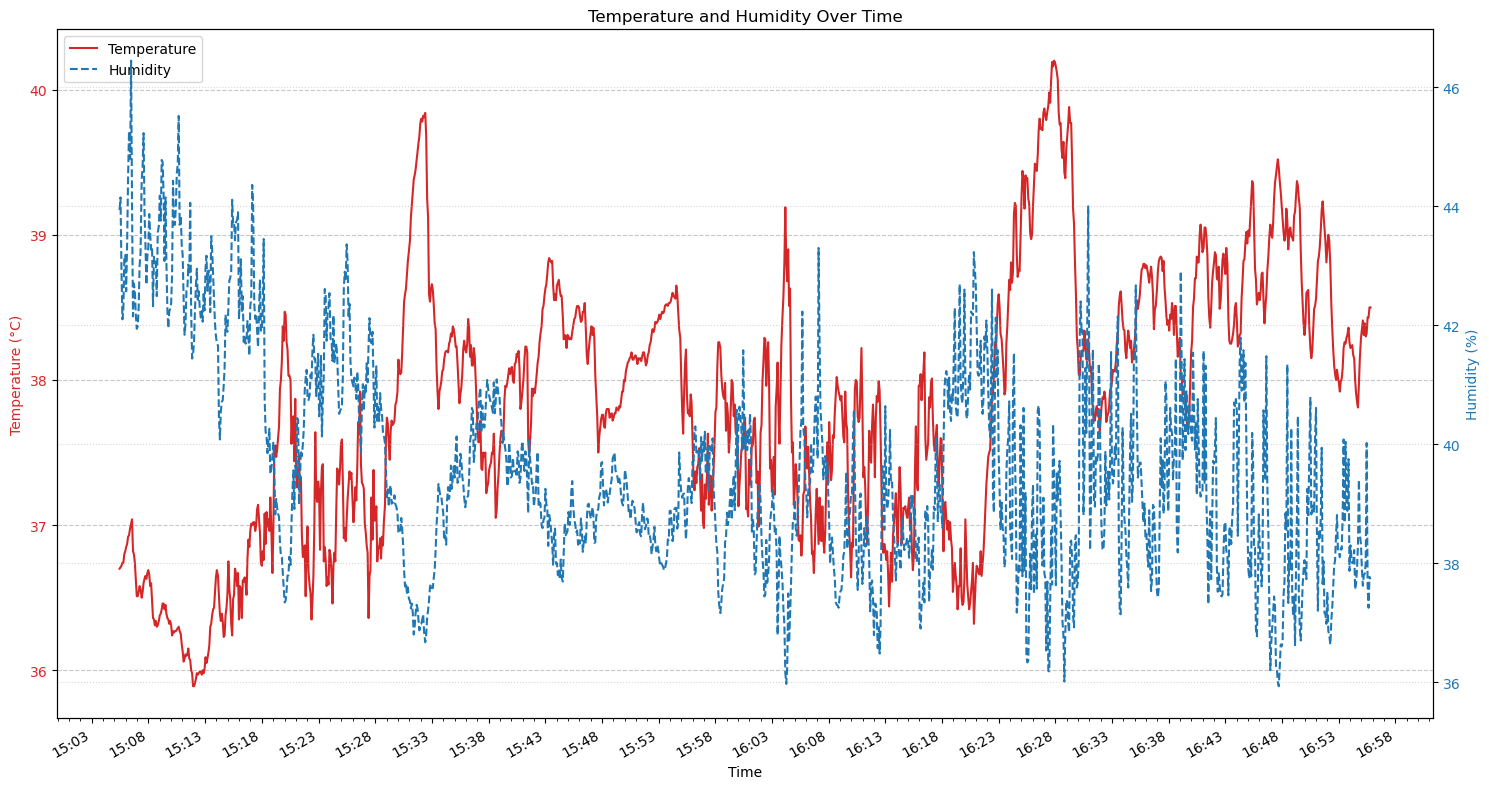

In [6]:
# Plot Temperature and Humidity
fig, ax1 = plt.subplots(figsize=(15, 8))

color_t ='tab:red'
color_rh = 'tab:blue'

# Plot Temperature on the primary y-axis (ax1)
ax1.plot(sensor1_aft_gdf['datetime'], sensor1_aft_gdf['Temperature_C'], label='Temperature', color=color_t)
ax1.set_xlabel('Time') # Clearer label
ax1.set_ylabel('Temperature (°C)', color=color_t)
ax1.tick_params(axis='y', labelcolor=color_t)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7) # Added grid on y-axis for temp

# Define the time format
time_formatter = mdates.DateFormatter("%H:%M",'America/New_York')

# Apply the formatter to the x-axis
ax1.xaxis.set_major_formatter(time_formatter)

# Adjust the locator for better time-based ticks. Major ticks labeled, minor ticks show tick mark
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=5)) # Ticks every 5 minute
ax1.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))

# Automatically format and rotate x-axis labels to prevent overlap
fig.autofmt_xdate()

# Create a secondary y-axis for Humidity
ax2 = ax1.twinx()

ax2.plot(sensor1_aft_gdf['datetime'], sensor1_aft_gdf['Humidity_RH'], label='Humidity', color=color_rh, linestyle='dashed')
ax2.set_ylabel('Humidity (%)', color=color_rh)
ax2.tick_params(axis='y', labelcolor=color_rh)
ax2.grid(True, axis='y', linestyle=':', alpha=0.5) # Added grid on y-axis for humidity with different style

# Combine legends from both axes to show them together
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Temperature and Humidity Over Time') # Updated title
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


In [7]:
gdfs = [sensor1_morn_gdf, sensor3_morn_gdf, sensor1_noon_gdf, sensor3_noon_gdf, sensor1_aft_gdf, sensor3_aft_gdf]

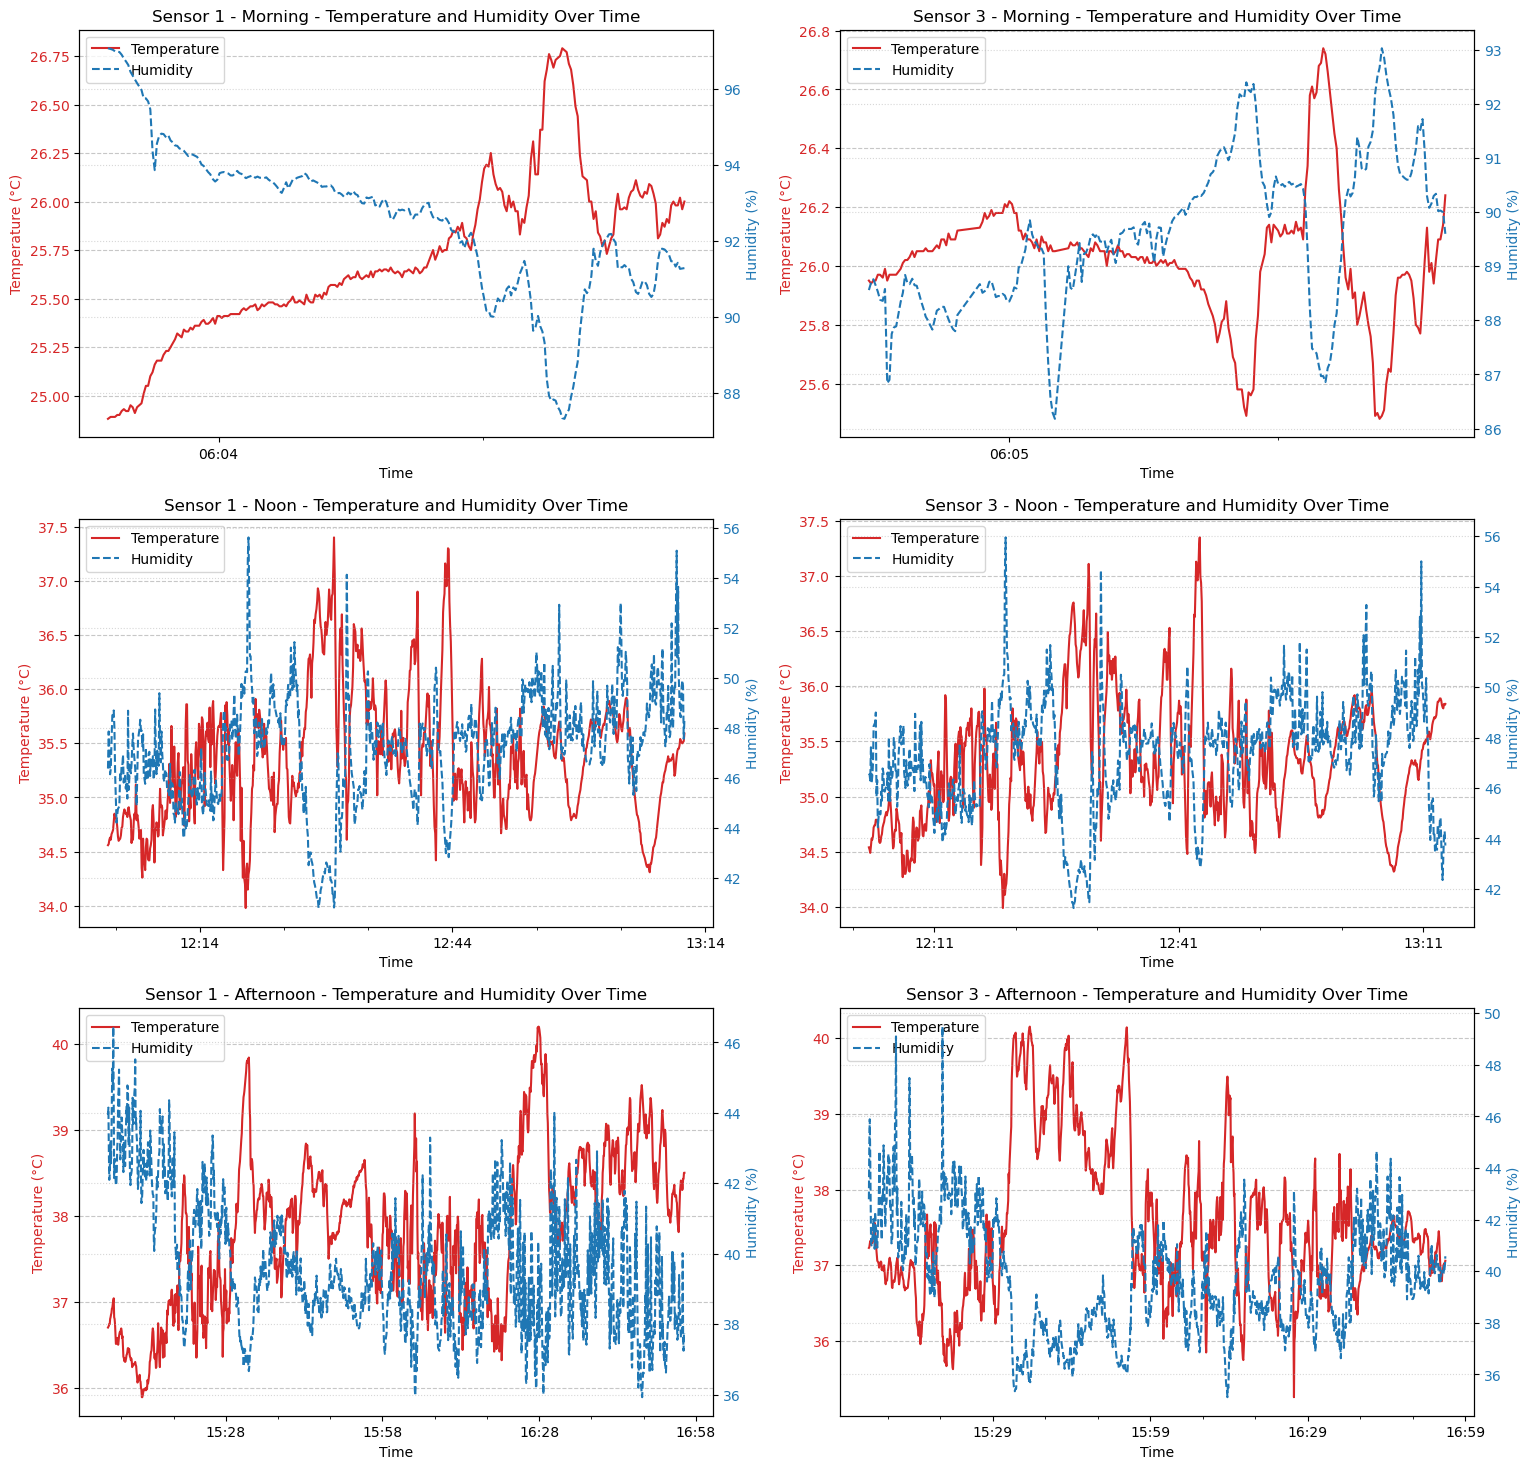

In [8]:
gdfs = [sensor1_morn_gdf, sensor3_morn_gdf, sensor1_noon_gdf, sensor3_noon_gdf, sensor1_aft_gdf, sensor3_aft_gdf]
gdf_names = [
    "Sensor 1 - Morning", "Sensor 3 - Morning",
    "Sensor 1 - Noon", "Sensor 3 - Noon",
    "Sensor 1 - Afternoon", "Sensor 3 - Afternoon"
]

# --- Create the 3x2 subplot figure ---
# The total figure size should accommodate all subplots comfortably.
# Adjust figsize as needed based on your screen and desired output size.
fig, axes = plt.subplots(3, 2, figsize=(18, 18)) # 3 rows, 2 columns
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

# Colors for plotting
color_t = 'tab:red'
color_rh = 'tab:blue'

# Iterate through each DataFrame and plot it in a subplot
for i, gdf in enumerate(gdfs):
    ax1 = axes[i] # Current primary y-axis for temperature
    ax2 = ax1.twinx() # Current secondary y-axis for humidity

    # Plot Temperature on the primary y-axis (ax1)
    ax1.plot(gdf['datetime'], gdf['Temperature_C'], label='Temperature', color=color_t)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Temperature (°C)', color=color_t)
    ax1.tick_params(axis='y', labelcolor=color_t)
    ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

    # Define the time format
    # Using 'America/New_York' timezone for consistency if your data has timezone info
    time_formatter = mdates.DateFormatter("%H:%M", "America/New_York")

    # Apply the formatter to the x-axis
    ax1.xaxis.set_major_formatter(time_formatter)

    # Adjust the locator for better time-based ticks.
    ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=30)) # Ticks every 30 minutes for clarity
    ax1.xaxis.set_minor_locator(mdates.MinuteLocator(interval=10)) # Minor ticks every 10 minutes

    # Create a secondary y-axis for Humidity
    ax2.plot(gdf['datetime'], gdf['Humidity_RH'], label='Humidity', color=color_rh, linestyle='dashed')
    ax2.set_ylabel('Humidity (%)', color=color_rh)
    ax2.tick_params(axis='y', labelcolor=color_rh)
    ax2.grid(True, axis='y', linestyle=':', alpha=0.5)

    # Combine legends from both axes to show them together
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    # Set subplot title
    ax1.set_title(f'{gdf_names[i]} - Temperature and Humidity Over Time')

# # Automatically format and rotate x-axis labels for the entire figure
# fig.autofmt_xdate()

# # Adjust layout to prevent labels from overlapping
# plt.tight_layout()

# Display the plot
plt.show()

In [9]:
morning_gdf = pd.concat([sensor1_morn_gdf, sensor3_morn_gdf])
afternoon_gdf = pd.concat([sensor1_aft_gdf, sensor3_aft_gdf])
morning_gdf

,System_Timestamp_UTC,Temperature_C,Humidity_RH,GPS_Timestamp_UTC,Latitude,Longitude,Altitude_m,Speed_mps,Climb_mps,Track_deg,Satellites,GPS_Fix_Type,datetime,geometry
6,2025-07-26 09:59:49+00:00,24.88,97.07,2025-07-26 09:59:49 UTC,34.021155,-81.000092,84.3,0.16,0.00,284.05,9.0,3D,2025-07-26 05:59:49-04:00,POINT (-81.00009 34.02116)
7,2025-07-26 09:59:55+00:00,24.89,97.05,2025-07-26 09:59:54 UTC,34.021157,-81.000090,84.3,0.40,0.00,303.49,9.0,3D,2025-07-26 05:59:55-04:00,POINT (-81.00009 34.02116)
8,2025-07-26 10:00:00+00:00,24.89,97.03,2025-07-26 09:59:59 UTC,34.021147,-81.000088,84.3,0.25,0.00,292.20,9.0,3D,2025-07-26 06:00:00-04:00,POINT (-81.00009 34.02115)
9,2025-07-26 10:00:05+00:00,24.89,96.99,2025-07-26 10:00:04 UTC,34.021127,-81.000088,84.2,0.10,-0.10,249.39,9.0,3D,2025-07-26 06:00:05-04:00,POINT (-81.00009 34.02113)
10,2025-07-26 10:00:10+00:00,24.90,96.98,2025-07-26 10:00:09 UTC,34.021115,-81.000080,84.1,0.40,0.00,241.87,9.0,3D,2025-07-26 06:00:10-04:00,POINT (-81.00008 34.02112)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,2025-07-26 10:20:54+00:00,26.02,90.34,2025-07-26 10:20:54 UTC,34.008817,-80.995170,70.9,12.24,-0.10,279.24,20.0,3D,2025-07-26 06:20:54-04:00,POINT (-80.99517 34.00882)
258,2025-07-26 10:20:59+00:00,26.09,90.02,2025-07-26 10:20:59 UTC,34.009002,-80.995792,73.2,12.43,0.88,289.80,8.0,3D,2025-07-26 06:20:59-04:00,POINT (-80.99579 34.009)
259,2025-07-26 10:21:04+00:00,26.09,90.03,2025-07-26 10:21:04 UTC,34.009198,-80.996363,72.2,11.51,-0.30,294.31,20.0,3D,2025-07-26 06:21:04-04:00,POINT (-80.99636 34.0092)
260,2025-07-26 10:21:10+00:00,26.14,90.00,2025-07-26 10:21:09 UTC,34.009382,-80.996923,73.0,11.13,-0.10,290.49,20.0,3D,2025-07-26 06:21:10-04:00,POINT (-80.99692 34.00938)


In [10]:
scale_min = morning_gdf['Temperature_C'].min()
scale_max = morning_gdf['Temperature_C'].max()
linear = cm.LinearColormap(["white", "blue", "green", "yellow", "red"], vmin=scale_min, vmax=scale_max)

# Create a map centered around the first valid GPS point
len_data = len(morning_gdf)
map_center = [morning_gdf['Latitude'].iloc[len_data//2], morning_gdf['Longitude'].iloc[len_data//2]]
m = folium.Map(location=map_center, zoom_start=15)

# Add markers for each GPS point
for idx, row in morning_gdf.iterrows():
    temp = row['Temperature_C']
        # Get the color from the colormap based on the temperature
    marker_color = linear(temp)

    folium.CircleMarker( # Using CircleMarker for better visibility of color
        location=[row['Latitude'], row['Longitude']],
        radius=5, # Size of the circle marker
        color=marker_color, # Outline color
        fill_color=marker_color,
        fill=True,
        fill_opacity=1,
        popup=f"Temp: {temp}°C",
    ).add_to(m)

# Add an Esri Satellite basemap
folium.TileLayer(tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',name='Esri Sat' , attr='Esri', overlay=False, control=True, show=False).add_to(m)

# the layercontrol itself
lc = folium.map.LayerControl(collapsed=False)
lc.add_to(m)

# Add color bar to bottom right
linear.add_to(m)

m.render()
m.get_root().script = folium.Element(
    m.get_root().script.render().replace('topright', 'bottomright')
)

# show map
m
# save map
# m.save(outfile='test.html')

In [11]:
afternoon_gdf = afternoon_gdf.dropna()
afternoon_gdf = afternoon_gdf[(afternoon_gdf['Speed_mps']>2.5) & (afternoon_gdf['Speed_mps']<15.64)]
scale_min = afternoon_gdf['Temperature_C'].min()
scale_max = afternoon_gdf['Temperature_C'].max()
linear = cm.LinearColormap(["blue", "white", "red"], vmin=scale_min, vmax=scale_max)

# Create a map centered around the first valid GPS point
len_data = len(afternoon_gdf)
map_center = [afternoon_gdf['Latitude'].iloc[len_data//2], afternoon_gdf['Longitude'].iloc[len_data//2]]
m = folium.Map(location=map_center, zoom_start=15)

# Add markers for each GPS point
for idx, row in afternoon_gdf.iterrows():
    time = row['datetime']
    temp = row['Temperature_C']
    rh = row['Humidity_RH']
    spd = row['Speed_mps']
        # Get the color from the colormap based on the temperature
    marker_color = linear(temp)

    folium.CircleMarker( # Using CircleMarker for better visibility of color
        location=[row['Latitude'], row['Longitude']],
        radius=5, # Size of the circle marker
        color=marker_color, # Outline color
        fill_color=marker_color,
        fill=True,
        fill_opacity=1,
        popup=f"Time: {time} local Temp: {temp}°C RH: {rh} Speed: {spd} mps"
    ).add_to(m)

# Add an Esri Satellite basemap
folium.TileLayer(tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',name='Esri Sat' , attr='Esri', overlay=False, control=True, show=False).add_to(m)

# the layercontrol itself
lc = folium.map.LayerControl(collapsed=False)
lc.add_to(m)

# Add color bar to bottom right
linear.add_to(m)

m.render()
m.get_root().script = folium.Element(
    m.get_root().script.render().replace('topright', 'bottomright')
)

# show map
m
# save map
# m.save(outfile='test.html')

In [ ]:
subset_afternoon_gdf = afternoon_gdf[(afternoon_gdf['datetime'].dt.time >= dt.time(15, 30)) & (afternoon_gdf['datetime'].dt.time <= dt.time(16, 0))]
subset_afternoon_gdf

In [19]:
afternoon_gdf

,System_Timestamp_UTC,Temperature_C,Humidity_RH,GPS_Timestamp_UTC,Latitude,Longitude,Altitude_m,Speed_mps,Climb_mps,Track_deg,Satellites,GPS_Fix_Type,datetime,geometry
79,2025-07-26 19:11:36+00:00,36.08,42.86,2025-07-26 19:11:36 UTC,34.021085,-81.000038,93.2,3.76,1.10,253.31,7.0,3D,2025-07-26 15:11:36-04:00,POINT (-81.00004 34.02108)
90,2025-07-26 19:12:31+00:00,35.99,42.31,2025-07-26 19:12:28 UTC,34.021212,-81.000155,131.9,2.62,0.70,5.44,8.0,3D,2025-07-26 15:12:31-04:00,POINT (-81.00016 34.02121)
108,2025-07-26 19:14:02+00:00,36.69,41.69,2025-07-26 19:14:02 UTC,34.021220,-81.000003,178.4,2.59,1.10,125.39,8.0,3D,2025-07-26 15:14:02-04:00,POINT (-81 34.02122)
109,2025-07-26 19:14:08+00:00,36.65,41.66,2025-07-26 19:14:07 UTC,34.021242,-80.999938,182.4,4.46,1.00,150.83,8.0,3D,2025-07-26 15:14:08-04:00,POINT (-80.99994 34.02124)
116,2025-07-26 19:14:43+00:00,36.24,41.28,2025-07-26 19:14:43 UTC,34.021410,-81.000318,177.7,6.47,-0.20,0.00,8.0,3D,2025-07-26 15:14:43-04:00,POINT (-81.00032 34.02141)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1110,2025-07-26 20:38:21+00:00,36.49,42.99,2025-07-26 20:38:20 UTC,34.020095,-81.000085,81.7,10.03,0.10,14.23,22.0,3D,2025-07-26 16:38:21-04:00,POINT (-81.00008 34.0201)
1111,2025-07-26 20:38:26+00:00,36.46,43.20,2025-07-26 20:38:25 UTC,34.020478,-80.999960,81.8,8.73,-0.10,14.86,22.0,3D,2025-07-26 16:38:26-04:00,POINT (-80.99996 34.02048)
1112,2025-07-26 20:38:31+00:00,36.35,42.74,2025-07-26 20:38:29 UTC,34.020748,-80.999870,81.6,6.96,0.10,13.55,22.0,3D,2025-07-26 16:38:31-04:00,POINT (-80.99987 34.02075)
1113,2025-07-26 20:38:37+00:00,36.58,42.16,2025-07-26 20:38:32 UTC,34.020863,-80.999825,80.8,4.47,-0.27,0.00,22.0,3D,2025-07-26 16:38:37-04:00,POINT (-80.99982 34.02086)


In [13]:

sensor3_27_aft_file = os.path.join(test_data, 'sensor03_data_20250727_131829.csv')
s3_aft_df, s3_aft_gdf = create_df(sensor3_27_aft_file)
s3_aft_gdf

,System_Timestamp_UTC,Temperature_C,Humidity_RH,GPS_Timestamp_UTC,Latitude,Longitude,Altitude_m,Speed_mps,Climb_mps,Track_deg,Satellites,GPS_Fix_Type,datetime,geometry
6,2025-07-27 17:19:00+00:00,36.82,45.02,2025-07-27 17:19:00 UTC,34.083185,-81.159057,82.9,0.36,0.0,0.00,14.0,3D,2025-07-27 13:19:00-04:00,POINT (-81.15906 34.08318)
7,2025-07-27 17:19:05+00:00,36.87,44.87,2025-07-27 17:19:05 UTC,34.083180,-81.159065,83.3,0.72,0.0,0.00,14.0,3D,2025-07-27 13:19:05-04:00,POINT (-81.15906 34.08318)
8,2025-07-27 17:19:10+00:00,36.96,44.89,2025-07-27 17:19:10 UTC,34.083128,-81.159123,83.0,2.87,-0.2,225.77,14.0,3D,2025-07-27 13:19:10-04:00,POINT (-81.15912 34.08313)
9,2025-07-27 17:19:15+00:00,37.08,44.83,2025-07-27 17:19:15 UTC,34.083017,-81.159280,82.3,4.63,0.0,232.73,14.0,3D,2025-07-27 13:19:15-04:00,POINT (-81.15928 34.08302)
10,2025-07-27 17:19:20+00:00,36.66,44.94,2025-07-27 17:19:20 UTC,34.082855,-81.159512,82.7,5.97,0.0,231.27,14.0,3D,2025-07-27 13:19:20-04:00,POINT (-81.15951 34.08286)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,2025-07-27 18:11:07+00:00,37.53,39.36,2025-07-27 18:11:07 UTC,34.016885,-81.040808,93.5,0.05,-0.1,148.97,20.0,3D,2025-07-27 14:11:07-04:00,POINT (-81.04081 34.01688)
626,2025-07-27 18:11:13+00:00,37.57,39.52,2025-07-27 18:11:12 UTC,34.016877,-81.040808,93.5,0.16,0.0,148.97,20.0,3D,2025-07-27 14:11:13-04:00,POINT (-81.04081 34.01688)
627,2025-07-27 18:11:18+00:00,37.58,39.52,2025-07-27 18:11:17 UTC,34.016875,-81.040810,93.4,0.16,0.0,148.97,20.0,3D,2025-07-27 14:11:18-04:00,POINT (-81.04081 34.01688)
628,2025-07-27 18:11:23+00:00,37.60,39.08,2025-07-27 18:11:22 UTC,34.016878,-81.040812,93.4,0.16,0.1,148.97,20.0,3D,2025-07-27 14:11:23-04:00,POINT (-81.04081 34.01688)


In [14]:
s3_aft_gdf = s3_aft_gdf.dropna()
s3_aft_gdf = s3_aft_gdf[(s3_aft_gdf['Speed_mps']>2.5) & (s3_aft_gdf['Speed_mps']<15.64)]
scale_min = s3_aft_gdf['Temperature_C'].min()
scale_max = s3_aft_gdf['Temperature_C'].max()
linear = cm.LinearColormap(["blue", "white", "red"], vmin=scale_min, vmax=scale_max)

# Create a map centered around the first valid GPS point
len_data = len(s3_aft_gdf)
map_center = [s3_aft_gdf['Latitude'].iloc[len_data//2], s3_aft_gdf['Longitude'].iloc[len_data//2]]
m = folium.Map(location=map_center, zoom_start=15)

# Add markers for each GPS point
for idx, row in s3_aft_gdf.iterrows():
    time = row['datetime']
    temp = row['Temperature_C']
    rh = row['Humidity_RH']
    spd = row['Speed_mps']
        # Get the color from the colormap based on the temperature
    marker_color = linear(temp)

    folium.CircleMarker( # Using CircleMarker for better visibility of color
        location=[row['Latitude'], row['Longitude']],
        radius=5, # Size of the circle marker
        color=marker_color, # Outline color
        fill_color=marker_color,
        fill=True,
        fill_opacity=1,
        popup=f"Time: {time} local Temp: {temp}°C RH: {rh} Speed: {spd} mps"
    ).add_to(m)

# Add an Esri Satellite basemap
folium.TileLayer(tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',name='Esri Sat' , attr='Esri', overlay=False, control=True, show=False).add_to(m)

# the layercontrol itself
lc = folium.map.LayerControl(collapsed=False)
lc.add_to(m)

# Add color bar to bottom right
linear.add_to(m)

m.render()
m.get_root().script = folium.Element(
    m.get_root().script.render().replace('topright', 'bottomright')
)

# show map
m
# save map
# m.save(outfile='test.html')